# 01. Exploratory Data Analysis

This notebook explores the structure, quality, and temporal characteristics of the dataset.

## Goals

1. Understand the dataset structure
2. Check data quality
3. Analyze the target variable
4. Explore transaction behavior
5. Analyze temporal patterns
6. Identify potential data leakage
7. Summarize findings for feature engineering

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

In [2]:
RAW_DIR = Path("../data/raw")

## 1. Load Data

The dataset contains:

- signal-level data
- transaction-level data
- a binary target indicating whether a signal was escalated

In [3]:
train_signals = pd.read_csv(
    RAW_DIR / "train_signals.csv"
)

test_signals = pd.read_csv(
    RAW_DIR / "test_signals.csv"
)

train_transactions = pd.read_parquet(
    RAW_DIR / "train_transactions.parquet"
)

test_transactions = pd.read_parquet(
    RAW_DIR / "test_transactions.parquet"
)

print("Train signals:", train_signals.shape)
print("Test signals:", test_signals.shape)
print("Train transactions:", train_transactions.shape)
print("Test transactions:", test_transactions.shape)

Train signals: (14000, 3)
Test signals: (6000, 2)
Train transactions: (6987663, 5)
Test transactions: (3027575, 5)


## 2. Dataset Structure

In [4]:
print("Train signals:")
print(train_signals.info())

print("\nTest signals:")
print(test_signals.info())

print("\nTrain transactions:")
print(train_transactions.info())

print("\nTest transactions:")
print(test_transactions.info())

Train signals:
<class 'pandas.DataFrame'>
RangeIndex: 14000 entries, 0 to 13999
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   signal_id      14000 non-null  str  
 1   signal_sanasi  14000 non-null  str  
 2   eskalatsiya    14000 non-null  int64
dtypes: int64(1), str(2)
memory usage: 588.0 KB
None

Test signals:
<class 'pandas.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   signal_id      6000 non-null   str  
 1   signal_sanasi  6000 non-null   str  
dtypes: str(2)
memory usage: 205.2 KB
None

Train transactions:
<class 'pandas.DataFrame'>
RangeIndex: 6987663 entries, 0 to 6987662
Data columns (total 5 columns):
 #   Column             Dtype         
---  ------             -----         
 0   signal_id          str           
 1   tranzaksiya_vaqti  datetime64[us]
 2   kirim_chiqim       st

In [5]:
display(train_signals.head())
display(test_signals.head())
display(train_transactions.head())
display(test_transactions.head())

,signal_id,signal_sanasi,eskalatsiya
0,SG_000002,2026-08-02,0
1,SG_000003,2025-12-15,0
2,SG_000004,2026-02-13,0
3,SG_000005,2026-02-05,0
4,SG_000006,2025-04-18,0


,signal_id,signal_sanasi
0,SG_000001,2025-07-11
1,SG_000007,2025-04-02
2,SG_000009,2025-01-23
3,SG_000010,2025-11-16
4,SG_000011,2026-06-03


,signal_id,tranzaksiya_vaqti,kirim_chiqim,tranzaksiya_turi,miqdor_indeksi
0,SG_016527,2024-07-06 08:47:18,chiqim,bank_otkazmasi,0.236245
1,SG_016527,2024-07-07 02:13:02,chiqim,bank_otkazmasi,1.130377
2,SG_016527,2024-07-08 11:15:12,kirim,karta,0.466360
3,SG_016527,2024-07-08 15:58:21,kirim,karta,-0.591761
4,SG_016527,2024-07-09 02:33:17,kirim,bank_otkazmasi,-1.108945


,signal_id,tranzaksiya_vaqti,kirim_chiqim,tranzaksiya_turi,miqdor_indeksi
0,SG_003509,2024-07-06 02:48:24,chiqim,karta,-0.645923
1,SG_003509,2024-07-06 04:43:44,chiqim,karta,-0.465810
2,SG_003509,2024-07-06 21:55:38,chiqim,karta,-0.961157
3,SG_003509,2024-07-07 10:31:32,kirim,karta,-0.691121
4,SG_003509,2024-07-07 13:42:55,chiqim,karta,-0.227328


In [6]:
display(train_signals.describe(include="all"))

,signal_id,signal_sanasi,eskalatsiya
count,14000,14000,14000.000000
unique,14000,730,NaN
top,SG_000002,2026-03-15,NaN
freq,1,43,NaN
mean,NaN,NaN,0.171786
std,NaN,NaN,0.377208
min,NaN,NaN,0.000000
25%,NaN,NaN,0.000000
50%,NaN,NaN,0.000000
75%,NaN,NaN,0.000000


In [7]:
display(
    train_transactions.describe(
        include="all"
    )
)

,signal_id,tranzaksiya_vaqti,kirim_chiqim,tranzaksiya_turi,miqdor_indeksi
count,6987663,6987663,6987663,6987663,6.987663e+06
unique,14000,NaN,2,4,NaN
top,SG_013858,NaN,kirim,karta,NaN
freq,2279,NaN,5286880,3758797,NaN
mean,NaN,2025-09-22 12:03:56.135657,NaN,NaN,-1.334381e-01
min,NaN,2024-07-05 00:31:36,NaN,NaN,-2.912314e+00
25%,NaN,2025-04-27 17:17:55.500000,NaN,NaN,-7.994047e-01
50%,NaN,2025-09-20 12:18:28,NaN,NaN,-2.442311e-01
75%,NaN,2026-02-15 20:31:00.500000,NaN,NaN,4.302461e-01
max,NaN,2026-12-31 00:00:00,NaN,NaN,6.691657e+00


## 3. Data Quality

In [8]:
def missing_report(df):
    report = pd.DataFrame({
        "missing_count": df.isna().sum(),
        "missing_percent": (
            df.isna().mean() * 100
        )
    })

    return report.sort_values(
        "missing_count",
        ascending=False
    )

In [9]:
print("Train signals")
display(missing_report(train_signals))

print("Test signals")
display(missing_report(test_signals))

print("Train transactions")
display(missing_report(train_transactions))

print("Test transactions")
display(missing_report(test_transactions))

Train signals


,missing_count,missing_percent
signal_id,0,0.0
signal_sanasi,0,0.0
eskalatsiya,0,0.0


Test signals


,missing_count,missing_percent
signal_id,0,0.0
signal_sanasi,0,0.0


Train transactions


,missing_count,missing_percent
signal_id,0,0.0
tranzaksiya_vaqti,0,0.0
kirim_chiqim,0,0.0
tranzaksiya_turi,0,0.0
miqdor_indeksi,0,0.0


Test transactions


,missing_count,missing_percent
signal_id,0,0.0
tranzaksiya_vaqti,0,0.0
kirim_chiqim,0,0.0
tranzaksiya_turi,0,0.0
miqdor_indeksi,0,0.0


### Duplicate Signal IDs

In [10]:
print(
    "Duplicate train signal IDs:",
    train_signals["signal_id"].duplicated().sum()
)

print(
    "Duplicate test signal IDs:",
    test_signals["signal_id"].duplicated().sum()
)

Duplicate train signal IDs: 0
Duplicate test signal IDs: 0


## 4. Target Analysis

The target variable `eskalatsiya` indicates whether a signal was escalated.

- `0` = dismissed
- `1` = escalated

In [11]:
target_counts = (
    train_signals["eskalatsiya"]
    .value_counts()
    .sort_index()
)

target_percent = (
    train_signals["eskalatsiya"]
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

target_summary = pd.DataFrame({
    "count": target_counts,
    "percentage": target_percent
})

target_summary

,count,percentage
eskalatsiya,,
0,11595,82.821429
1,2405,17.178571


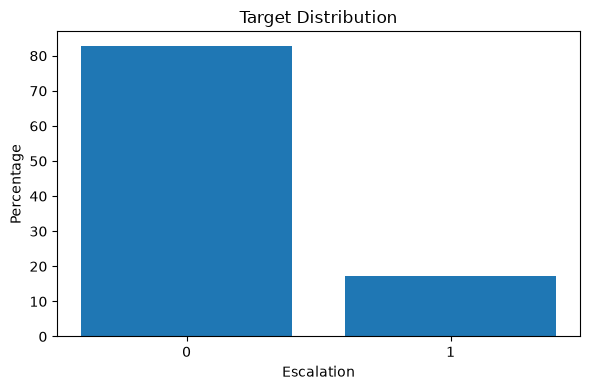

In [12]:
plt.figure(figsize=(6, 4))

plt.bar(
    target_summary.index.astype(str),
    target_summary["percentage"]
)

plt.xlabel("Escalation")
plt.ylabel("Percentage")
plt.title("Target Distribution")

plt.tight_layout()
plt.show()

## 5. Temporal Analysis

In [13]:
train_signals["signal_sanasi"] = pd.to_datetime(
    train_signals["signal_sanasi"]
)

test_signals["signal_sanasi"] = pd.to_datetime(
    test_signals["signal_sanasi"]
)

train_transactions["tranzaksiya_vaqti"] = pd.to_datetime(
    train_transactions["tranzaksiya_vaqti"]
)

test_transactions["tranzaksiya_vaqti"] = pd.to_datetime(
    test_transactions["tranzaksiya_vaqti"]
)

In [14]:
print(
    "Train signal date range:",
    train_signals["signal_sanasi"].min(),
    "→",
    train_signals["signal_sanasi"].max()
)

print(
    "Test signal date range:",
    test_signals["signal_sanasi"].min(),
    "→",
    test_signals["signal_sanasi"].max()
)

Train signal date range: 2025-01-01 00:00:00 → 2026-12-31 00:00:00
Test signal date range: 2025-01-01 00:00:00 → 2026-12-31 00:00:00


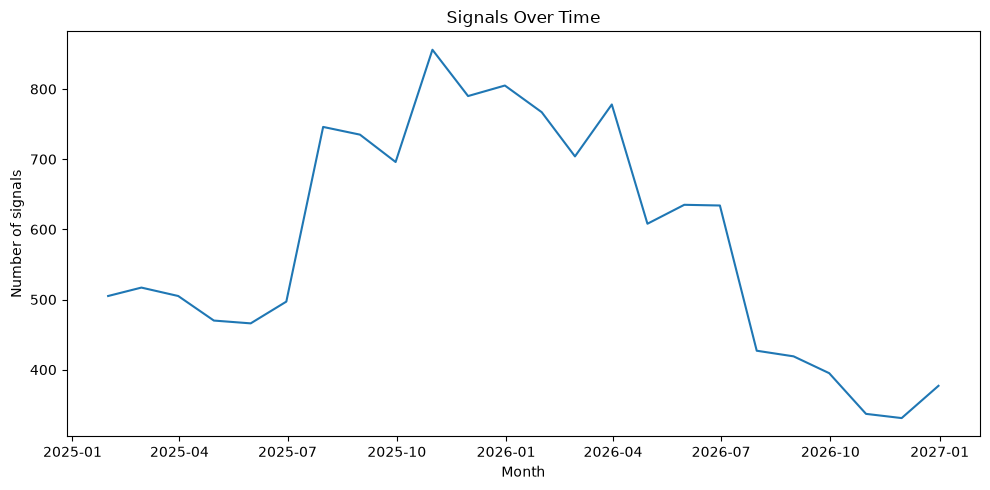

In [15]:
monthly_signals = (
    train_signals
    .set_index("signal_sanasi")
    .resample("ME")
    .size()
)

plt.figure(figsize=(10, 5))

plt.plot(
    monthly_signals.index,
    monthly_signals.values
)

plt.xlabel("Month")
plt.ylabel("Number of signals")
plt.title("Signals Over Time")

plt.tight_layout()
plt.show()

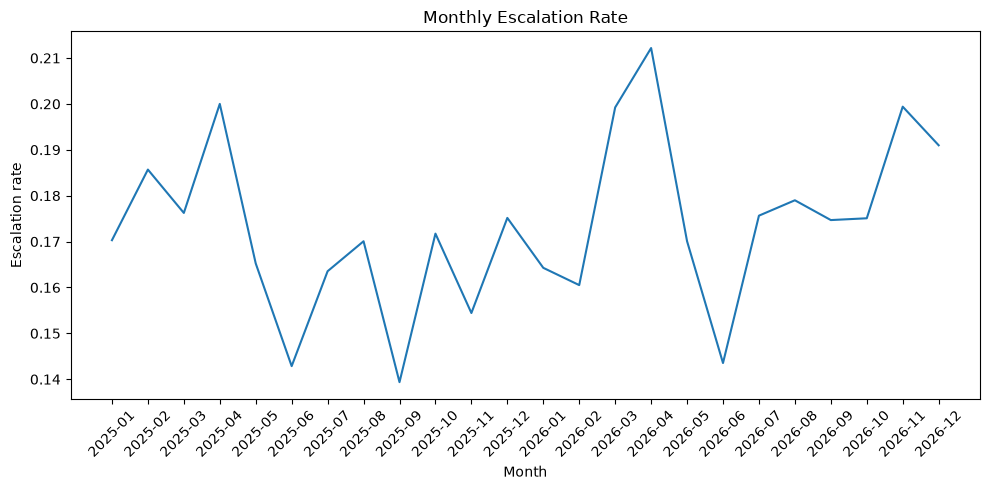

In [16]:
monthly_target = (
    train_signals
    .assign(
        month=train_signals["signal_sanasi"].dt.to_period("M")
    )
    .groupby("month")["eskalatsiya"]
    .mean()
)

plt.figure(figsize=(10, 5))

plt.plot(
    monthly_target.index.astype(str),
    monthly_target.values
)

plt.xlabel("Month")
plt.ylabel("Escalation rate")
plt.title("Monthly Escalation Rate")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [17]:
print(
    "Train transaction date range:",
    train_transactions["tranzaksiya_vaqti"].min(),
    "→",
    train_transactions["tranzaksiya_vaqti"].max()
)

print(
    "Test transaction date range:",
    test_transactions["tranzaksiya_vaqti"].min(),
    "→",
    test_transactions["tranzaksiya_vaqti"].max()
)

Train transaction date range: 2024-07-05 00:31:36 → 2026-12-31 00:00:00
Test transaction date range: 2024-07-05 00:42:26 → 2026-12-31 00:00:00


## 6. Transaction Analysis

Each signal is associated with a number of historical transactions.

In [18]:
train_tx_count = (
    train_transactions
    .groupby("signal_id")
    .size()
)

print(
    "Mean transactions per signal:",
    train_tx_count.mean()
)

print(
    "Median transactions per signal:",
    train_tx_count.median()
)

print(
    "Minimum:",
    train_tx_count.min()
)

print(
    "Maximum:",
    train_tx_count.max()
)

Mean transactions per signal: 499.1187857142857
Median transactions per signal: 461.0
Minimum: 1
Maximum: 2279


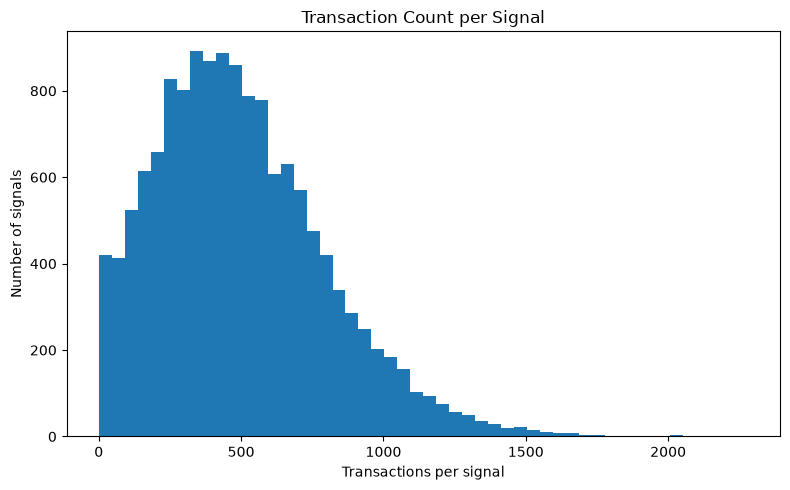

In [19]:
plt.figure(figsize=(8, 5))

plt.hist(
    train_tx_count,
    bins=50
)

plt.xlabel("Transactions per signal")
plt.ylabel("Number of signals")
plt.title("Transaction Count per Signal")

plt.tight_layout()
plt.show()

In [20]:
direction_counts = (
    train_transactions["kirim_chiqim"]
    .value_counts()
)

direction_counts

kirim_chiqim
kirim     5286880
chiqim    1700783
Name: count, dtype: int64

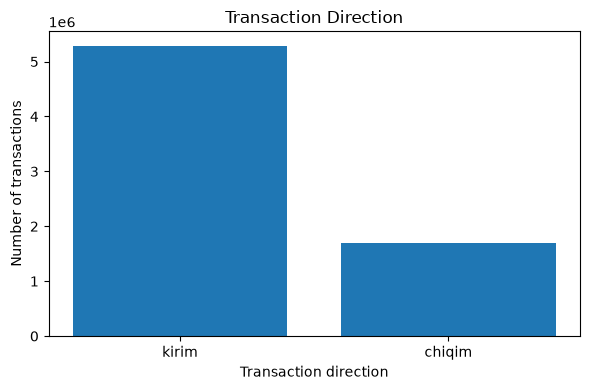

In [21]:
plt.figure(figsize=(6, 4))

plt.bar(
    direction_counts.index,
    direction_counts.values
)

plt.xlabel("Transaction direction")
plt.ylabel("Number of transactions")
plt.title("Transaction Direction")

plt.tight_layout()
plt.show()

In [22]:
type_counts = (
    train_transactions["tranzaksiya_turi"]
    .value_counts()
)

type_counts

tranzaksiya_turi
karta             3758797
bank_otkazmasi    2754687
naqd               442346
xalqaro             31833
Name: count, dtype: int64

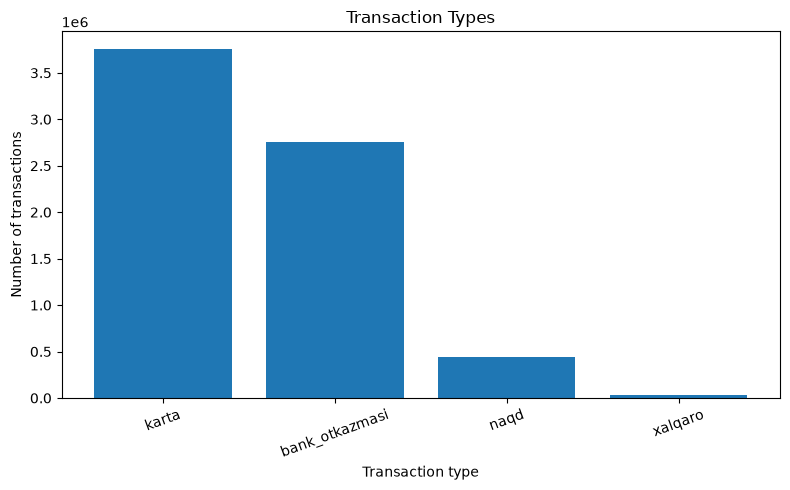

In [23]:
plt.figure(figsize=(8, 5))

plt.bar(
    type_counts.index,
    type_counts.values
)

plt.xlabel("Transaction type")
plt.ylabel("Number of transactions")
plt.title("Transaction Types")

plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

## 7. Amount Index Analysis

`miqdor_indeksi` is treated as a numerical transaction-level variable.

Its distribution is inspected to identify scale, spread, and potential outliers.

In [24]:
print(
    train_transactions["miqdor_indeksi"]
    .describe()
)

count    6.987663e+06
mean    -1.334381e-01
std      9.810576e-01
min     -2.912314e+00
25%     -7.994047e-01
50%     -2.442311e-01
75%      4.302461e-01
max      6.691657e+00
Name: miqdor_indeksi, dtype: float64


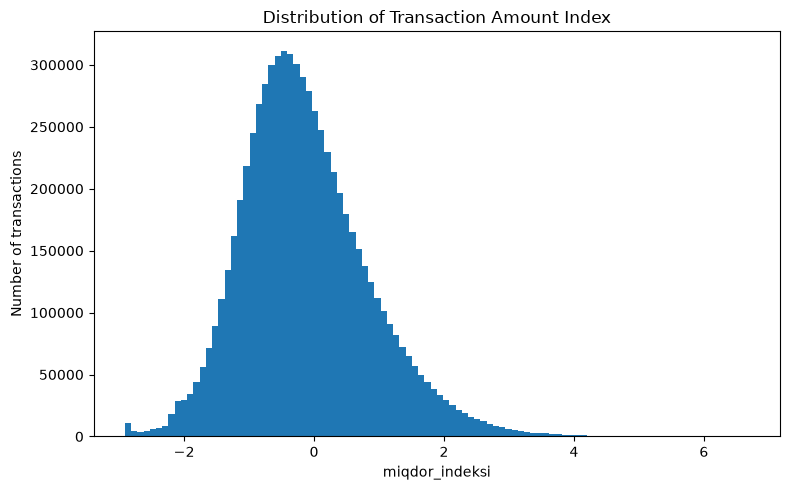

In [25]:
plt.figure(figsize=(8, 5))

plt.hist(
    train_transactions["miqdor_indeksi"],
    bins=100
)

plt.xlabel("miqdor_indeksi")
plt.ylabel("Number of transactions")
plt.title("Distribution of Transaction Amount Index")

plt.tight_layout()
plt.show()

In [26]:
eda_tx = train_transactions.merge(
    train_signals[
        ["signal_id", "eskalatsiya"]
    ],
    on="signal_id",
    how="left"
)

signal_summary = (
    eda_tx
    .groupby("signal_id")
    .agg(
        transaction_count=(
            "signal_id",
            "size"
        ),
        miqdor_mean=(
            "miqdor_indeksi",
            "mean"
        ),
        miqdor_min=(
            "miqdor_indeksi",
            "min"
        ),
        miqdor_max=(
            "miqdor_indeksi",
            "max"
        ),
        chiqim_count=(
            "kirim_chiqim",
            lambda x: (x == "chiqim").sum()
        )
    )
    .reset_index()
)

signal_summary = signal_summary.merge(
    train_signals[
        ["signal_id", "eskalatsiya"]
    ],
    on="signal_id",
    how="left"
)

In [27]:
display(
    signal_summary
    .groupby("eskalatsiya")["transaction_count"]
    .describe()
)

,count,mean,std,min,25%,50%,75%,max
eskalatsiya,,,,,,,,
0,11595.0,494.005692,298.482480,1.0,272.0,455.0,672.0,2279.0
1,2405.0,523.770062,303.013927,1.0,299.0,493.0,704.0,2039.0


In [28]:
display(
    signal_summary
    .groupby("eskalatsiya")["chiqim_count"]
    .describe()
)

,count,mean,std,min,25%,50%,75%,max
eskalatsiya,,,,,,,,
0,11595.0,119.842087,82.397308,0.0,59.0,104.0,165.0,570.0
1,2405.0,129.402911,84.956597,0.0,66.0,114.0,177.0,552.0


In [29]:
display(
    signal_summary
    .groupby("eskalatsiya")[
        [
            "miqdor_mean",
            "miqdor_min",
            "miqdor_max"
        ]
    ]
    .mean()
)

,miqdor_mean,miqdor_min,miqdor_max
eskalatsiya,,,
0,-0.045223,-2.327775,3.052149
1,-0.116132,-2.353069,2.881728


In [30]:
signal_summary["transaction_count_bin"] = pd.qcut(
    signal_summary["transaction_count"],
    q=5,
    duplicates="drop"
)

transaction_rate = (
    signal_summary
    .groupby(
        "transaction_count_bin",
        observed=True
    )["eskalatsiya"]
    .mean()
)

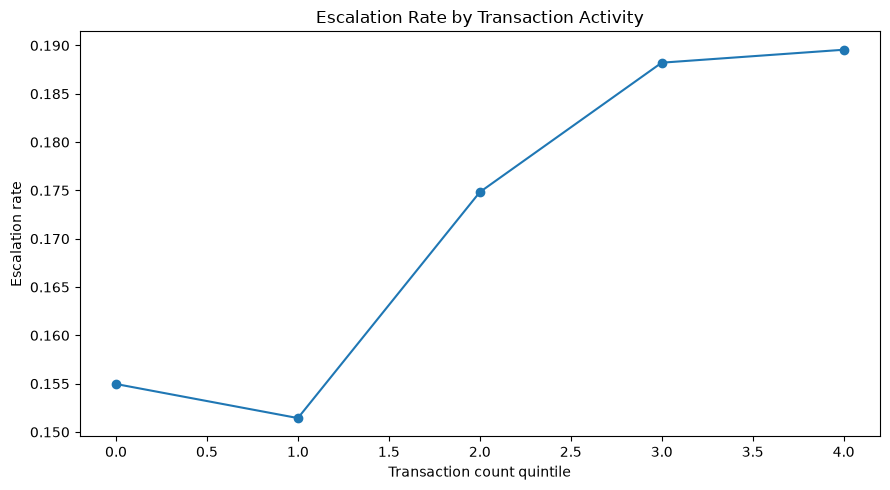

In [31]:
plt.figure(figsize=(9, 5))

plt.plot(
    range(len(transaction_rate)),
    transaction_rate.values,
    marker="o"
)

plt.xlabel("Transaction count quintile")
plt.ylabel("Escalation rate")
plt.title("Escalation Rate by Transaction Activity")

plt.tight_layout()
plt.show()

## 8. Temporal Leakage Investigation

The model must only use transactions that were available at the time of the signal.

Transactions occurring after the signal date would represent future information and must not be used for training.

In [32]:
leakage_check = train_transactions.merge(
    train_signals[
        ["signal_id", "signal_sanasi"]
    ],
    on="signal_id",
    how="left"
)

future_transactions = (
    leakage_check["tranzaksiya_vaqti"]
    > leakage_check["signal_sanasi"]
)

print(
    "Transactions after signal:",
    future_transactions.sum()
)

print(
    "Percentage:",
    future_transactions.mean() * 100
)

Transactions after signal: 840
Percentage: 0.012021186482519262


### Leakage Finding

A small number of transactions occur after the signal timestamp.

These transactions must be excluded during feature engineering because they would introduce future information into the model.

The filtering step is implemented in `02_feature_engineering.ipynb`.

## 9. EDA Summary

### Dataset

- 14,000 training signals
- 6,000 test signals
- Approximately 7 million training transactions
- Approximately 3 million test transactions

### Target

- 82.82% of training signals are not escalated
- 17.18% are escalated
- The target is imbalanced

### Transactions

- Each signal is associated with many transactions
- Incoming transactions are more common than outgoing transactions
- `karta` and `bank_otkazmasi` are the dominant transaction types

### Time

- Signal dates span 2025-01-01 to 2026-12-31
- Monthly escalation rates vary over time
- Temporal validation is therefore important

### Leakage

- Some transactions occur after the signal timestamp
- These transactions must be excluded from feature engineering

### Feature Engineering Direction

The EDA suggests using:

- transaction counts
- incoming/outgoing transaction statistics
- transaction type counts
- recent transaction activity
- statistical properties of `miqdor_indeksi`
- temporal information available before the signal